# EDA

In [1]:
# Load required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pprint
import warnings
warnings.filterwarnings('ignore')  # Suppress all warnings


# Load the datasets
transaction_data = pd.read_csv(r"QVI_transaction_data.csv")
customer_data = pd.read_csv(r"QVI_purchase_behaviour.csv")

## 1. Examine transaction data

In [2]:
transaction_data.head(10)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
5,43604,4,4074,2982,57,Old El Paso Salsa Dip Tomato Mild 300g,1,5.1
6,43601,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7
7,43601,4,4196,3539,24,Grain Waves Sweet Chilli 210g,1,3.6
8,43332,5,5026,4525,42,Doritos Corn Chip Mexican Jalapeno 150g,1,3.9
9,43330,7,7150,6900,52,Grain Waves Sour Cream&Chives 210G,2,7.2


In [3]:
# transaction_data[transaction_data['PROD_NAME']=='OLD']

transaction_data[transaction_data['PROD_NAME'].str.contains('Old')]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
5,43604,4,4074,2982,57,Old El Paso Salsa Dip Tomato Mild 300g,1,5.1
25,43600,39,39144,35506,57,Old El Paso Salsa Dip Tomato Mild 300g,1,5.1
71,43327,94,94233,93956,65,Old El Paso Salsa Dip Chnky Tom Ht300g,1,5.1
87,43327,116,116184,120270,59,Old El Paso Salsa Dip Tomato Med 300g,1,5.1
114,43328,157,157185,159562,59,Old El Paso Salsa Dip Tomato Med 300g,2,10.2
...,...,...,...,...,...,...,...,...
264594,43539,261,261323,261068,65,Old El Paso Salsa Dip Chnky Tom Ht300g,2,10.2
264607,43411,262,262061,261665,65,Old El Paso Salsa Dip Chnky Tom Ht300g,2,10.2
264615,43335,262,262084,261793,57,Old El Paso Salsa Dip Tomato Mild 300g,2,10.2
264628,43466,264,264165,262926,65,Old El Paso Salsa Dip Chnky Tom Ht300g,2,10.2


### Check if data types are correct

In [4]:
transaction_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


### Correct wrong data types

In [5]:
transaction_data['DATE'] = pd.to_datetime(transaction_data['DATE'], origin='1899-12-30', unit='D')

In [6]:
transaction_data.dtypes

DATE              datetime64[ns]
STORE_NBR                  int64
LYLTY_CARD_NBR             int64
TXN_ID                     int64
PROD_NBR                   int64
PROD_NAME                 object
PROD_QTY                   int64
TOT_SALES                float64
dtype: object

### Check if data contains only Chips products

In [7]:
transaction_data['PROD_NAME'].describe()

count                                     264836
unique                                       114
top       Kettle Mozzarella   Basil & Pesto 175g
freq                                        3304
Name: PROD_NAME, dtype: object

In [8]:
# Look at some unique product names
transaction_data['PROD_NAME'].unique()[:10]

array(['Natural Chip        Compny SeaSalt175g',
       'CCs Nacho Cheese    175g',
       'Smiths Crinkle Cut  Chips Chicken 170g',
       'Smiths Chip Thinly  S/Cream&Onion 175g',
       'Kettle Tortilla ChpsHny&Jlpno Chili 150g',
       'Old El Paso Salsa   Dip Tomato Mild 300g',
       'Smiths Crinkle Chips Salt & Vinegar 330g',
       'Grain Waves         Sweet Chilli 210g',
       'Doritos Corn Chip Mexican Jalapeno 150g',
       'Grain Waves Sour    Cream&Chives 210G'], dtype=object)

In [9]:
# Split product names into words
product_words = transaction_data['PROD_NAME'].str.split(expand=True).stack().str.lower()
product_words.value_counts()


175g        60561
chips       49770
150g        43131
kettle      41288
&           35565
            ...  
sunbites     1432
pc           1431
ncc          1419
garden       1419
fries        1418
Name: count, Length: 218, dtype: int64

In [10]:
product_words.value_counts().head(10)

175g        60561
chips       49770
150g        43131
kettle      41288
&           35565
smiths      28860
salt        27976
cheese      27890
pringles    25102
134g        25102
Name: count, dtype: int64

In [11]:
import re

# Tokenize all product names, convert to lowercase
words = transaction_data['PROD_NAME'].str.lower().str.split()

# Flatten the list of lists into a single series
all_words = pd.Series([word for sublist in words for word in sublist])

# Remove words with digits or special characters
clean_words = all_words[~all_words.str.contains(r'[^a-z]', regex=True)]

# Count frequency
word_counts = clean_words.value_counts()

# View most common clean words
print(word_counts.head(20))


chips       49770
kettle      41288
smiths      28860
salt        27976
cheese      27890
pringles    25102
doritos     24962
crinkle     23960
corn        22063
original    21560
cut         20754
chip        18645
salsa       18094
chicken     15407
sea         14145
thins       14075
sour        13882
crisps      12607
vinegar     12402
chilli      12389
Name: count, dtype: int64


In [12]:
print(words)
print("\n----------\n")
print(all_words)
print("\n----------\n")
print(clean_words)

0                    [natural, chip, compny, seasalt175g]
1                              [ccs, nacho, cheese, 175g]
2            [smiths, crinkle, cut, chips, chicken, 170g]
3             [smiths, chip, thinly, s/cream&onion, 175g]
4          [kettle, tortilla, chpshny&jlpno, chili, 150g]
                               ...                       
264831    [kettle, sweet, chilli, and, sour, cream, 175g]
264832                 [tostitos, splash, of, lime, 175g]
264833                          [doritos, mexicana, 170g]
264834     [doritos, corn, chip, mexican, jalapeno, 150g]
264835                 [tostitos, splash, of, lime, 175g]
Name: PROD_NAME, Length: 264836, dtype: object

----------

0              natural
1                 chip
2               compny
3          seasalt175g
4                  ccs
              ...     
1359079       tostitos
1359080         splash
1359081             of
1359082           lime
1359083           175g
Length: 1359084, dtype: object

----------

0    

### Remove products that are not chips

In [13]:
# Mark rows with 'salsa' in the product name (case insensitive)
transaction_data['SALSA'] = transaction_data['PROD_NAME'].str.lower().str.contains("salsa")

In [14]:
transaction_data.head(10)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,SALSA
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,False
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,False
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,False
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,False
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,False
5,2019-05-19,4,4074,2982,57,Old El Paso Salsa Dip Tomato Mild 300g,1,5.1,True
6,2019-05-16,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7,False
7,2019-05-16,4,4196,3539,24,Grain Waves Sweet Chilli 210g,1,3.6,False
8,2018-08-20,5,5026,4525,42,Doritos Corn Chip Mexican Jalapeno 150g,1,3.9,False
9,2018-08-18,7,7150,6900,52,Grain Waves Sour Cream&Chives 210G,2,7.2,False


In [15]:
# Filter out salsa rows
transaction_data = transaction_data[transaction_data['SALSA'] == False]

# Drop the temporary column
transaction_data.drop(columns=['SALSA'], inplace=True)

In [16]:
transaction_data.head(10)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
6,2019-05-16,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7
7,2019-05-16,4,4196,3539,24,Grain Waves Sweet Chilli 210g,1,3.6
8,2018-08-20,5,5026,4525,42,Doritos Corn Chip Mexican Jalapeno 150g,1,3.9
9,2018-08-18,7,7150,6900,52,Grain Waves Sour Cream&Chives 210G,2,7.2
10,2019-05-17,7,7215,7176,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7


In [17]:
# Filter rows where 'PROD_NAME' contains the word 'Kettle' (case-insensitive)
kettle_products = transaction_data[transaction_data['PROD_NAME'].str.contains('kettle', case=False, na=False)]

# Display the results
kettle_products.head()


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
11,2018-08-20,8,8294,8221,114,Kettle Sensations Siracha Lime 150g,5,23.0
23,2018-08-19,36,36302,33188,32,Kettle Sea Salt And Vinegar 175g,1,5.4
24,2018-08-15,38,38142,34181,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,2,9.2
27,2019-05-15,41,41423,38393,46,Kettle Original 175g,1,5.4


In [18]:
transaction_data.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,246742,246742.000000,2.467420e+05,2.467420e+05,246742.000000,246742.000000,246742.000000
mean,2018-12-30 01:19:01.211467520,135.051098,1.355310e+05,1.351311e+05,56.351789,1.908062,7.321322
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.700000
25%,2018-09-30 00:00:00,70.000000,7.001500e+04,6.756925e+04,26.000000,2.000000,5.800000
50%,2018-12-30 00:00:00,130.000000,1.303670e+05,1.351830e+05,53.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.000000,2.030840e+05,2.026538e+05,87.000000,2.000000,8.800000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000
std,NaN,76.787096,8.071528e+04,7.814772e+04,33.695428,0.659831,3.077828


In [19]:
# Check for nulls in each column
transaction_data.isnull().sum()


DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

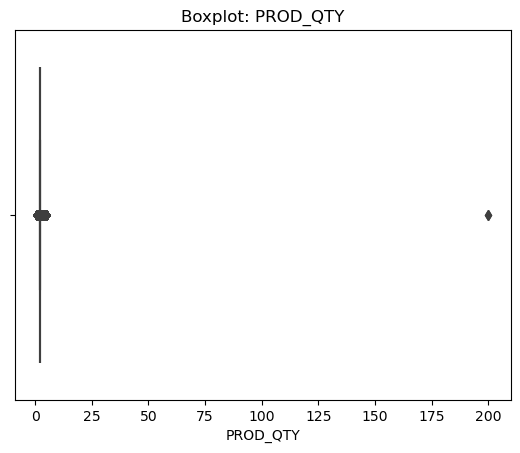

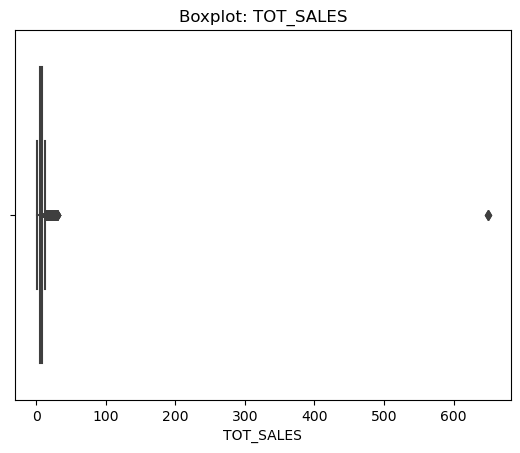

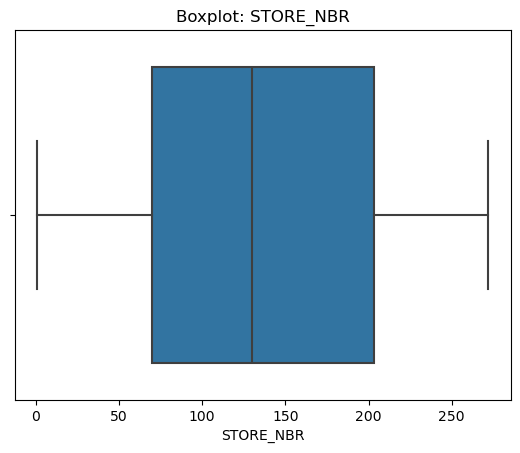

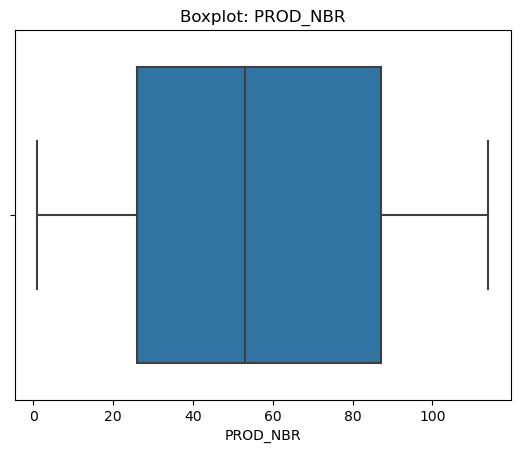

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in ['PROD_QTY', 'TOT_SALES', 'STORE_NBR', 'PROD_NBR']:
    sns.boxplot(x=transaction_data[col])
    plt.title(f"Boxplot: {col}")
    plt.show()



In [21]:
# Filter rows where quantity = 200
outliers = transaction_data[transaction_data['PROD_QTY'] == 200]

# Display the outlier transactions
outliers


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


In [22]:
# Get the loyalty card number of that customer
outlier_customer = outliers['LYLTY_CARD_NBR'].iloc[0]
print("LYLTY_CARD_NBR: ", outlier_customer)

# Remove this customer from the dataset
transaction_data = transaction_data[transaction_data['LYLTY_CARD_NBR'] != outlier_customer]


LYLTY_CARD_NBR:  226000


In [23]:
# Count transactions per date
transactions_by_day = transaction_data.groupby('DATE').size().reset_index(name='N')

transactions_by_day

,DATE,N
0,2018-07-01,663
1,2018-07-02,650
2,2018-07-03,674
3,2018-07-04,669
4,2018-07-05,660
...,...,...
359,2019-06-26,657
360,2019-06-27,669
361,2019-06-28,673
362,2019-06-29,703


In [24]:
# a check to see if the counts above are correct
transaction_data[transaction_data['DATE'] == '2018-07-01']

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
916,2018-07-01,47,47142,42540,14,Smiths Crnkle Chip Orgnl Big Bag 380g,2,11.8
1054,2018-07-01,55,55073,48884,99,Pringles Sthrn FriedChicken 134g,2,7.4
1055,2018-07-01,55,55073,48884,91,CCs Tasty Cheese 175g,2,4.2
1166,2018-07-01,58,58351,54374,102,Kettle Mozzarella Basil & Pesto 175g,2,10.8
1285,2018-07-01,68,68193,65598,44,Thins Chips Light& Tangy 175g,2,6.6
...,...,...,...,...,...,...,...,...
262622,2018-07-01,179,179213,180682,32,Kettle Sea Salt And Vinegar 175g,2,10.8
263059,2018-07-01,195,195403,195303,75,Cobs Popd Sea Salt Chips 110g,1,3.8
263317,2018-07-01,205,205430,204503,37,Smiths Thinly Swt Chli&S/Cream175G,1,3.0
264550,2018-07-01,259,259226,258901,67,RRD Chilli& Coconut 150g,2,5.4


In [25]:
# Check if there are 365 days
print(f"Unique dates: {transactions_by_day['DATE'].nunique()}")

Unique dates: 364


In [26]:
import pandas as pd

# Create full date range
full_dates = pd.DataFrame({'DATE': pd.date_range('2018-07-01', '2019-06-30')})

# Join with transaction count
transactions_by_day_full = pd.merge(full_dates, transactions_by_day, on='DATE', how='left')
transactions_by_day_full['N'] = transactions_by_day_full['N'].fillna(0)

print("Missing date:")
transactions_by_day_full[transactions_by_day_full['N']==0]

Missing date:


,DATE,N
177,2018-12-25,0.0


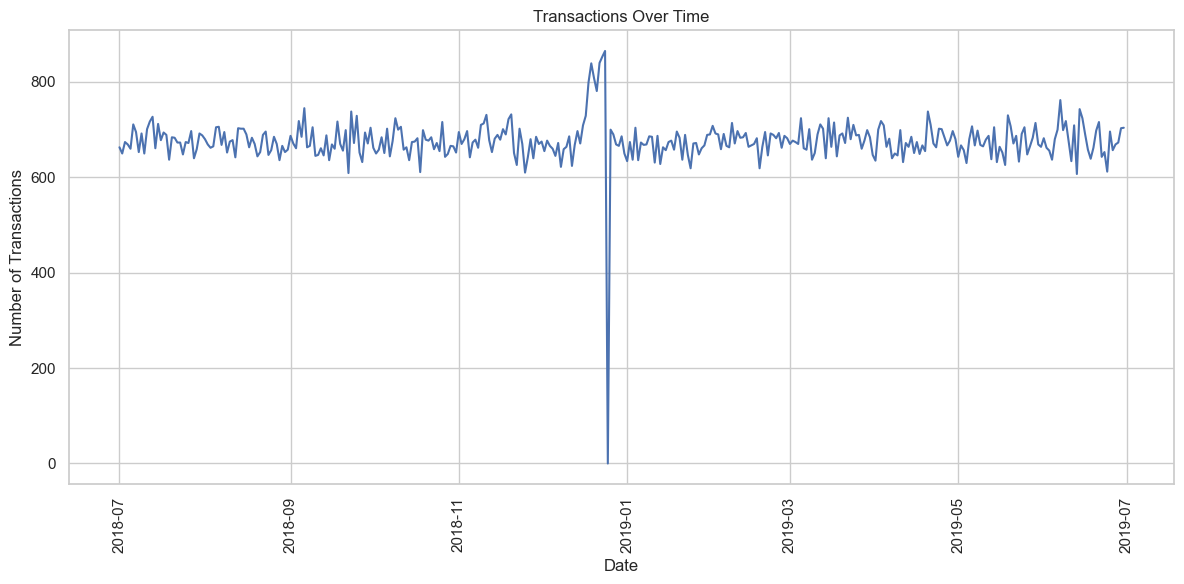

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))
sns.lineplot(data=transactions_by_day_full, x='DATE', y='N')
plt.title("Transactions Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


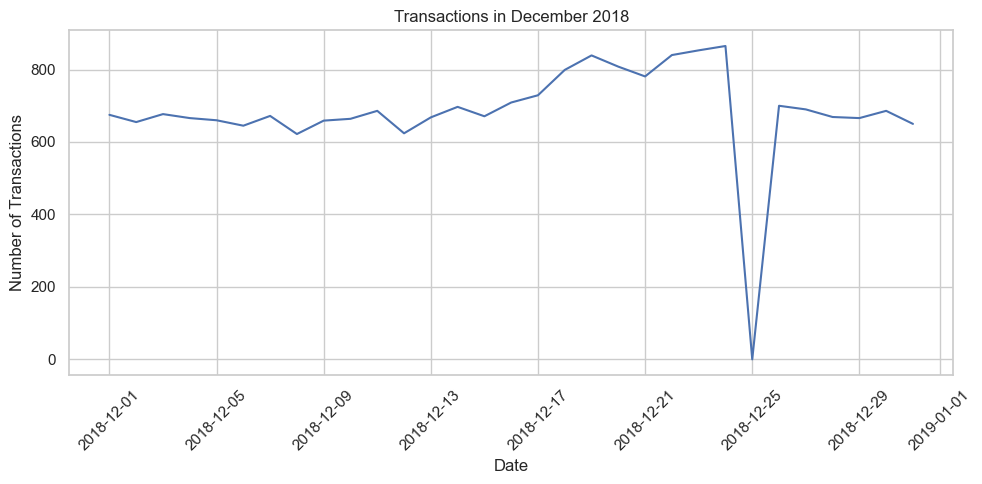

In [28]:
december_txns = transactions_by_day_full[
    (transactions_by_day_full['DATE'] >= '2018-12-01') & 
    (transactions_by_day_full['DATE'] <= '2018-12-31')
]

plt.figure(figsize=(10, 5))
sns.lineplot(data=december_txns, x='DATE', y='N')
plt.title("Transactions in December 2018")
plt.xlabel("Date")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [29]:
# Extract numeric part from product name (assumed to be grams)
transaction_data['PACK_SIZE'] = transaction_data['PROD_NAME'].str.extract(r'(\d+)').astype(int)

# Check the sizes
transaction_data['PACK_SIZE'].value_counts().sort_index()


PACK_SIZE
70      1507
90      3008
110    22387
125     1454
134    25102
135     3257
150    40203
160     2970
165    15297
170    19983
175    66390
180     1468
190     2995
200     4473
210     6272
220     1564
250     3169
270     6285
330    12540
380     6416
Name: count, dtype: int64

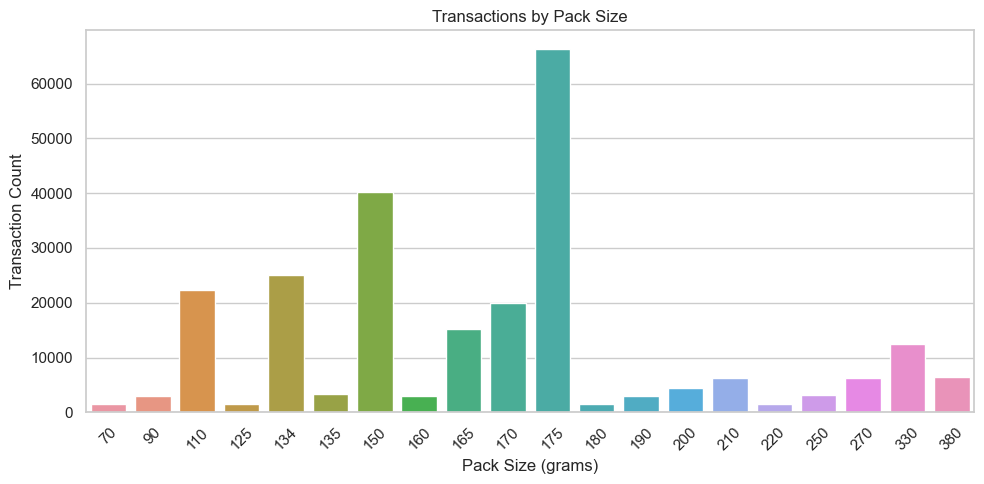

In [30]:
plt.figure(figsize=(10, 5))
sns.countplot(data=transaction_data, x='PACK_SIZE', order=sorted(transaction_data['PACK_SIZE'].dropna().unique()))
plt.title("Transactions by Pack Size")
plt.xlabel("Pack Size (grams)")
plt.ylabel("Transaction Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [31]:
transaction_data['BRAND'] = transaction_data['PROD_NAME'].str.split().str[0]
transaction_data

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,Natural
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175,CCs
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170,Smiths
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175,Smiths
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150,Kettle
...,...,...,...,...,...,...,...,...,...,...
264831,2019-03-09,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8,175,Kettle
264832,2018-08-13,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4,175,Tostitos
264833,2018-11-06,272,272379,270187,51,Doritos Mexicana 170g,2,8.8,170,Doritos
264834,2018-12-27,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8,150,Doritos


In [32]:
print(transaction_data['BRAND'].unique())
print(transaction_data['BRAND'].unique().shape)

['Natural' 'CCs' 'Smiths' 'Kettle' 'Grain' 'Doritos' 'Twisties' 'WW'
 'Thins' 'Burger' 'NCC' 'Cheezels' 'Infzns' 'Red' 'Pringles' 'Dorito'
 'Infuzions' 'Smith' 'GrnWves' 'Tyrrells' 'Cobs' 'French' 'RRD' 'Tostitos'
 'Cheetos' 'Woolworths' 'Snbts' 'Sunbites']
(28,)


In [33]:
transaction_data[transaction_data['BRAND']=='OLD']

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND


In [34]:
import pandas as pd

# Define the actual brand name mapping
brand_mapping = {
    'RED': 'RRD',
    'SNBTS': 'SUNBITES',
    'INFZNS': 'INFUZIONS',
    'WW': 'WOOLWORTHS',
    'SMITH': 'SMITHS',
    'NCC': 'NATURAL',
    'DORITO': 'DORITOS',
    'GRAIN': 'GRNWVES'
}

# Normalize brand names (uppercase and strip whitespace)
transaction_data['BRAND'] = transaction_data['BRAND'].astype(str).str.strip().str.upper()

# Replace all duplicate/alias names with standardized names
transaction_data['BRAND'] = transaction_data['BRAND'].map(brand_mapping).fillna(transaction_data['BRAND'])

# Final check
print(transaction_data['BRAND'].value_counts().sort_index())


BRAND
BURGER         1564
CCS            4551
CHEETOS        2927
CHEEZELS       4603
COBS           9693
DORITOS       25224
FRENCH         1418
GRNWVES        7740
INFUZIONS     14201
KETTLE        41288
NATURAL        7469
PRINGLES      25102
RRD           16321
SMITHS        30353
SUNBITES       3008
THINS         14075
TOSTITOS       9471
TWISTIES       9454
TYRRELLS       6442
WOOLWORTHS    11836
Name: count, dtype: int64


In [35]:
print(transaction_data['BRAND'].unique())
print(transaction_data['BRAND'].unique().shape)

['NATURAL' 'CCS' 'SMITHS' 'KETTLE' 'GRNWVES' 'DORITOS' 'TWISTIES'
 'WOOLWORTHS' 'THINS' 'BURGER' 'CHEEZELS' 'INFUZIONS' 'RRD' 'PRINGLES'
 'TYRRELLS' 'COBS' 'FRENCH' 'TOSTITOS' 'CHEETOS' 'SUNBITES']
(20,)


In [36]:
transaction_data[transaction_data['BRAND']=='RED']

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND


In [37]:
transaction_data[transaction_data['BRAND']=='RRD']

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND
28,2018-08-15,41,41486,38472,13,Red Rock Deli Thai Chilli&Lime 150g,1,2.7,150,RRD
34,2018-08-16,51,51100,46802,48,Red Rock Deli Sp Salt & Truffle 150G,1,2.7,150,RRD
92,2019-05-18,120,120226,123743,67,RRD Chilli& Coconut 150g,1,2.7,150,RRD
118,2019-05-19,164,164183,164919,67,RRD Chilli& Coconut 150g,1,2.7,150,RRD
140,2018-08-16,191,191200,192940,53,RRD Sweet Chilli & Sour Cream 165g,1,3.0,165,RRD
...,...,...,...,...,...,...,...,...,...,...
264775,2018-12-01,269,269204,266270,58,Red Rock Deli Chikn&Garlic Aioli 150g,2,5.4,150,RRD
264778,2019-06-02,269,269204,266273,67,RRD Chilli& Coconut 150g,2,5.4,150,RRD
264781,2019-02-08,269,269222,266383,11,RRD Pc Sea Salt 165g,2,6.0,165,RRD
264810,2018-09-21,271,271051,268507,13,Red Rock Deli Thai Chilli&Lime 150g,2,5.4,150,RRD


# Customer Data

In [38]:
customer_data.head(10)

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream
5,1007,YOUNG SINGLES/COUPLES,Budget
6,1009,NEW FAMILIES,Premium
7,1010,YOUNG SINGLES/COUPLES,Mainstream
8,1011,OLDER SINGLES/COUPLES,Mainstream
9,1012,OLDER FAMILIES,Mainstream


In [39]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [40]:
customer_data.describe()

,LYLTY_CARD_NBR
count,7.263700e+04
mean,1.361859e+05
std,8.989293e+04
min,1.000000e+03
25%,6.620200e+04
50%,1.340400e+05
75%,2.033750e+05
max,2.373711e+06


In [41]:
customer_data.shape

(72637, 3)

In [42]:
customer_data['LYLTY_CARD_NBR'].unique()[:10]

array([1000, 1002, 1003, 1004, 1005, 1007, 1009, 1010, 1011, 1012],
      dtype=int64)

In [43]:
print(customer_data['LIFESTAGE'].value_counts())
print('---'*20)
print(customer_data['PREMIUM_CUSTOMER'].value_counts())  # if this column exists

LIFESTAGE
RETIREES                  14805
OLDER SINGLES/COUPLES     14609
YOUNG SINGLES/COUPLES     14441
OLDER FAMILIES             9780
YOUNG FAMILIES             9178
MIDAGE SINGLES/COUPLES     7275
NEW FAMILIES               2549
Name: count, dtype: int64
------------------------------------------------------------
PREMIUM_CUSTOMER
Mainstream    29245
Budget        24470
Premium       18922
Name: count, dtype: int64


In [44]:
data = pd.merge(transaction_data, customer_data, on='LYLTY_CARD_NBR', how='left')


In [45]:
data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175,CCS,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170,SMITHS,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175,SMITHS,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150,KETTLE,MIDAGE SINGLES/COUPLES,Budget


In [46]:
data['LIFESTAGE'].unique()

array(['YOUNG SINGLES/COUPLES', 'MIDAGE SINGLES/COUPLES', 'NEW FAMILIES',
       'OLDER FAMILIES', 'OLDER SINGLES/COUPLES', 'RETIREES',
       'YOUNG FAMILIES'], dtype=object)

In [47]:
data['PREMIUM_CUSTOMER'].unique()

array(['Premium', 'Budget', 'Mainstream'], dtype=object)

In [48]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246740 entries, 0 to 246739
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   DATE              246740 non-null  datetime64[ns]
 1   STORE_NBR         246740 non-null  int64         
 2   LYLTY_CARD_NBR    246740 non-null  int64         
 3   TXN_ID            246740 non-null  int64         
 4   PROD_NBR          246740 non-null  int64         
 5   PROD_NAME         246740 non-null  object        
 6   PROD_QTY          246740 non-null  int64         
 7   TOT_SALES         246740 non-null  float64       
 8   PACK_SIZE         246740 non-null  int32         
 9   BRAND             246740 non-null  object        
 10  LIFESTAGE         246740 non-null  object        
 11  PREMIUM_CUSTOMER  246740 non-null  object        
dtypes: datetime64[ns](1), float64(1), int32(1), int64(5), object(4)
memory usage: 21.6+ MB


In [49]:
# Save merged dataset to CSV
data.to_csv("QVI_data.csv", index=False)

## Data analysis on customer segments

### Total Sales by Lifestage and Premium_Customer

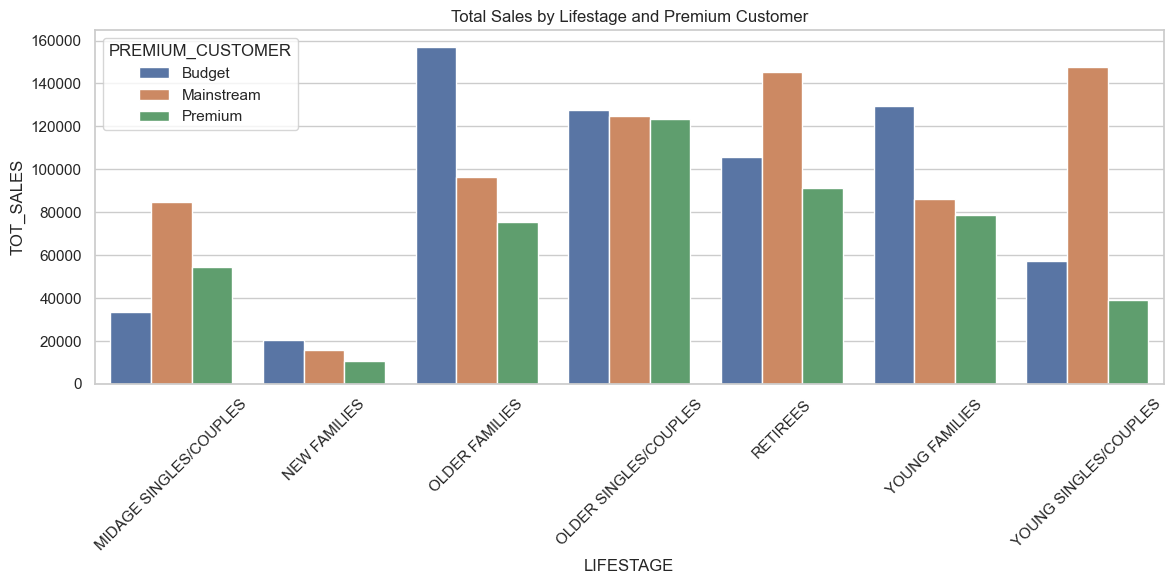

In [50]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Group and sum total sales
sales_summary = data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().reset_index()

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=sales_summary, x='LIFESTAGE', y='TOT_SALES', hue='PREMIUM_CUSTOMER')
plt.xticks(rotation=45)
plt.title("Total Sales by Lifestage and Premium Customer")
plt.tight_layout()
plt.show()


Budget - Older Families, Mainstream - Young Singles/couples, and Mainstream - Retirees contribute highly to sales. 

Question to ask - Are the higher sales due to there being more customers who buy chips in these categories?

### Number of Unique Customers by Segment

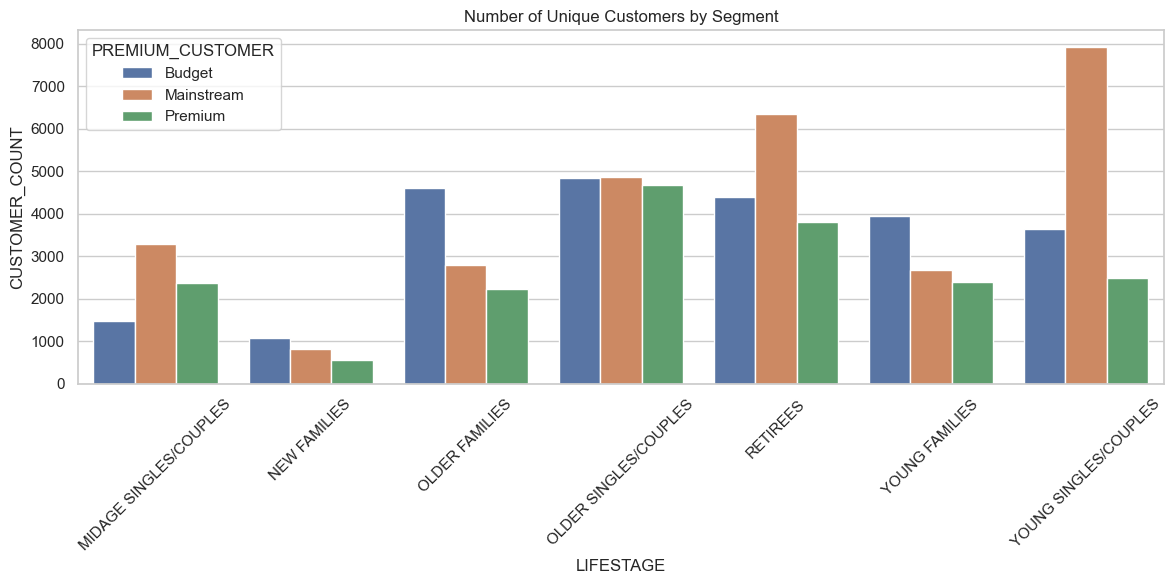

In [51]:
# Drop duplicates to count unique customers per segment
unique_customers = data[['LYLTY_CARD_NBR', 'LIFESTAGE', 'PREMIUM_CUSTOMER']].drop_duplicates()
customer_counts = unique_customers.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).size().reset_index(name='CUSTOMER_COUNT')

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=customer_counts, x='LIFESTAGE', y='CUSTOMER_COUNT', hue='PREMIUM_CUSTOMER')
plt.xticks(rotation=45)
plt.title("Number of Unique Customers by Segment")
plt.tight_layout()
plt.show()


Analysis: There are more Mainstream - young singles/couples and Mainstream - retirees who buy lots of chips. This contributes to there being more sales to these customer segments but this is not a major driver for the Budget - Older families segment. Higher sales may also be driven by more units of chips being bought per customer. Let's have a look at this next.

### Avg Number of Chip Units bought per Customer

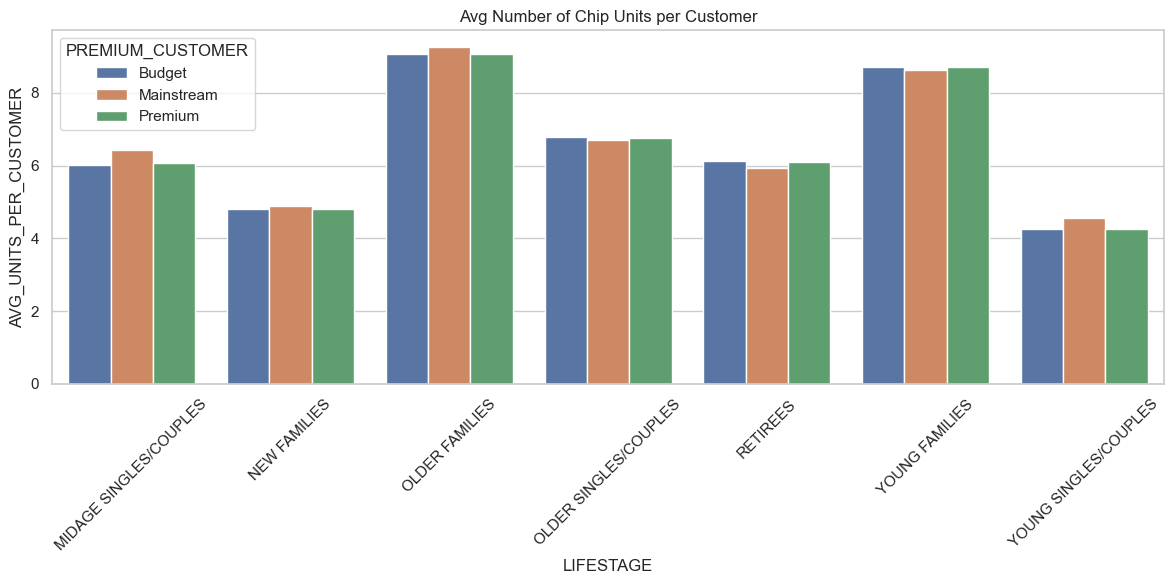

In [52]:
# Total units by segment
total_units = data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['PROD_QTY'].sum().reset_index()

# Merge with customer counts
avg_units = pd.merge(total_units, customer_counts, on=['LIFESTAGE', 'PREMIUM_CUSTOMER'])
avg_units['AVG_UNITS_PER_CUSTOMER'] = avg_units['PROD_QTY'] / avg_units['CUSTOMER_COUNT']

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=avg_units, x='LIFESTAGE', y='AVG_UNITS_PER_CUSTOMER', hue='PREMIUM_CUSTOMER')
plt.xticks(rotation=45)
plt.title("Avg Number of Chip Units per Customer")
plt.tight_layout()
plt.show()


Older families and young families in general buy more chips per customer.

Let's also investigate the average price per unit chips bought for each customer segment as this is also a driver of total sales.

### Average Price per Unit by Segment

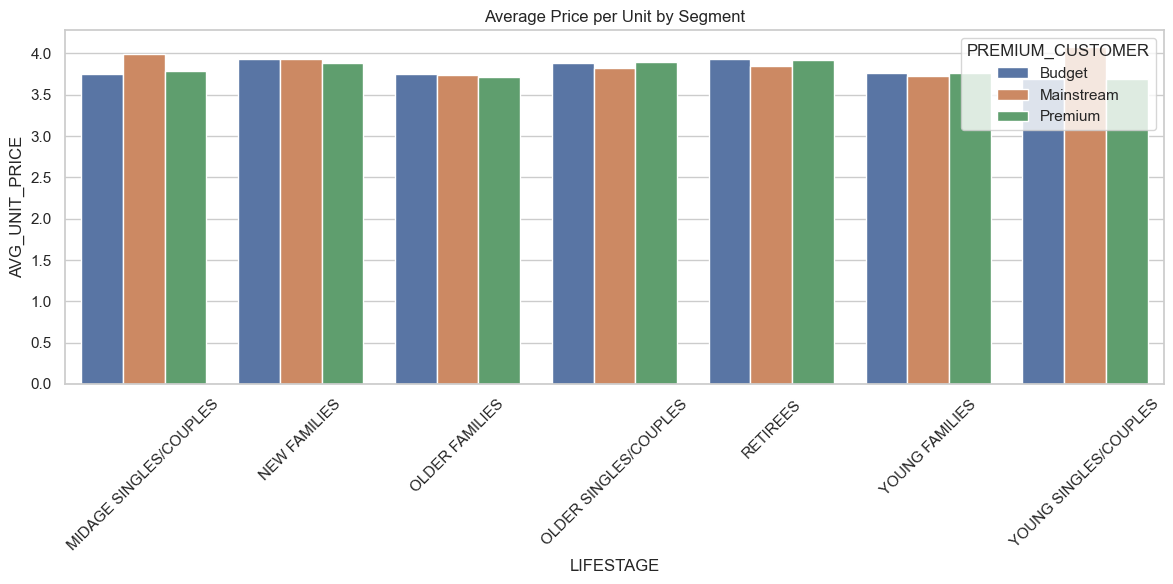

In [53]:
# Total sales / total units
price_per_unit = data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])[['TOT_SALES', 'PROD_QTY']].sum().reset_index()
price_per_unit['AVG_UNIT_PRICE'] = price_per_unit['TOT_SALES'] / price_per_unit['PROD_QTY']

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=price_per_unit, x='LIFESTAGE', y='AVG_UNIT_PRICE', hue='PREMIUM_CUSTOMER')
plt.xticks(rotation=45)
plt.title("Average Price per Unit by Segment")
plt.tight_layout()
plt.show()


Analysis - Mainstream midage and young singles and couples are more willing to pay more per packet of chips compared to their budget and premium counterparts. This may be due to premium shoppers being more likely to buy healthy snacks and when they buy chips, this is mainly for entertainment purposes rather than their own consumption. This is also supported by there being fewer premium midage and young singles and couples buying chips compared to their mainstream counterparts. As the difference in average price per unit isn't large, we can check if this difference is statistically different.


### Perform a t-test to see if the difference is significant.

In [54]:
import pandas as pd
from scipy.stats import ttest_ind

# Calculate price per unit
data['price'] = data['TOT_SALES'] / data['PROD_QTY']

# Define relevant lifestages
target_lifestages = ['YOUNG SINGLES/COUPLES', 'MIDAGE SINGLES/COUPLES']

# Split into two groups
mainstream = data[
    (data['LIFESTAGE'].isin(target_lifestages)) &
    (data['PREMIUM_CUSTOMER'] == 'Mainstream')
]['price']

others = data[
    (data['LIFESTAGE'].isin(target_lifestages)) &
    (data['PREMIUM_CUSTOMER'] != 'Mainstream')
]['price']

# Perform Welch's t-test (equal_var=False)
t_stat, p_value = ttest_ind(mainstream, others, alternative='greater', equal_var=False)

# Output the result
print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_value:.2e}")
print(f"Mean price (Mainstream): {mainstream.mean():.2f}")
print(f"Mean price (Others): {others.mean():.2f}")


T-statistic: 37.62
P-value: 3.48e-306
Mean price (Mainstream): 4.04
Mean price (Others): 3.71


In [55]:
if p_value < 0.05:
    print("The difference is statistically significant.")
else:
    print("The difference is NOT statistically significant.")


The difference is statistically significant.


### Deep dive into specific customer segments for insights

In [56]:
# Target segment: Mainstream - Young Singles/Couples
segment1 = data[(data['LIFESTAGE'] == "YOUNG SINGLES/COUPLES") & (data['PREMIUM_CUSTOMER'] == "Mainstream")]
other = data[~((data['LIFESTAGE'] == "YOUNG SINGLES/COUPLES") & (data['PREMIUM_CUSTOMER'] == "Mainstream"))]
# Total quantity purchased in each group
quantity_segment1 = segment1['PROD_QTY'].sum()
quantity_other = other['PROD_QTY'].sum()

# Proportion of quantity by brand in each group
quantity_segment1_by_brand = (
    segment1.groupby('BRAND')['PROD_QTY'].sum() / quantity_segment1
).reset_index(name='targetSegment')

quantity_other_by_brand = (
    other.groupby('BRAND')['PROD_QTY'].sum() / quantity_other
).reset_index(name='other')

# Merge and calculate brand affinity
brand_proportions = pd.merge(quantity_segment1_by_brand, quantity_other_by_brand, on='BRAND')
brand_proportions['affinityToBrand'] = brand_proportions['targetSegment'] / brand_proportions['other']
brand_proportions = brand_proportions.sort_values(by='affinityToBrand', ascending=False)

print(brand_proportions)


         BRAND  targetSegment     other  affinityToBrand
18    TYRRELLS       0.031553  0.025692         1.228095
17    TWISTIES       0.046184  0.037877         1.219319
5      DORITOS       0.122761  0.101075         1.214553
9       KETTLE       0.197985  0.165553         1.195897
16    TOSTITOS       0.045411  0.037978         1.195713
11    PRINGLES       0.119420  0.100635         1.186670
4         COBS       0.044638  0.039049         1.143124
8    INFUZIONS       0.064679  0.057065         1.133435
15       THINS       0.060373  0.056986         1.059423
7      GRNWVES       0.032712  0.031188         1.048873
3     CHEEZELS       0.017971  0.018647         0.963753
13      SMITHS       0.096370  0.124584         0.773536
6       FRENCH       0.003948  0.005758         0.685569
2      CHEETOS       0.008033  0.012067         0.665733
12         RRD       0.043810  0.067494         0.649091
10     NATURAL       0.019600  0.030854         0.635241
1          CCS       0.011180  

In [57]:
# Filter target segment
target_segment = data[(data['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') &
                      (data['PREMIUM_CUSTOMER'] == 'Mainstream')]



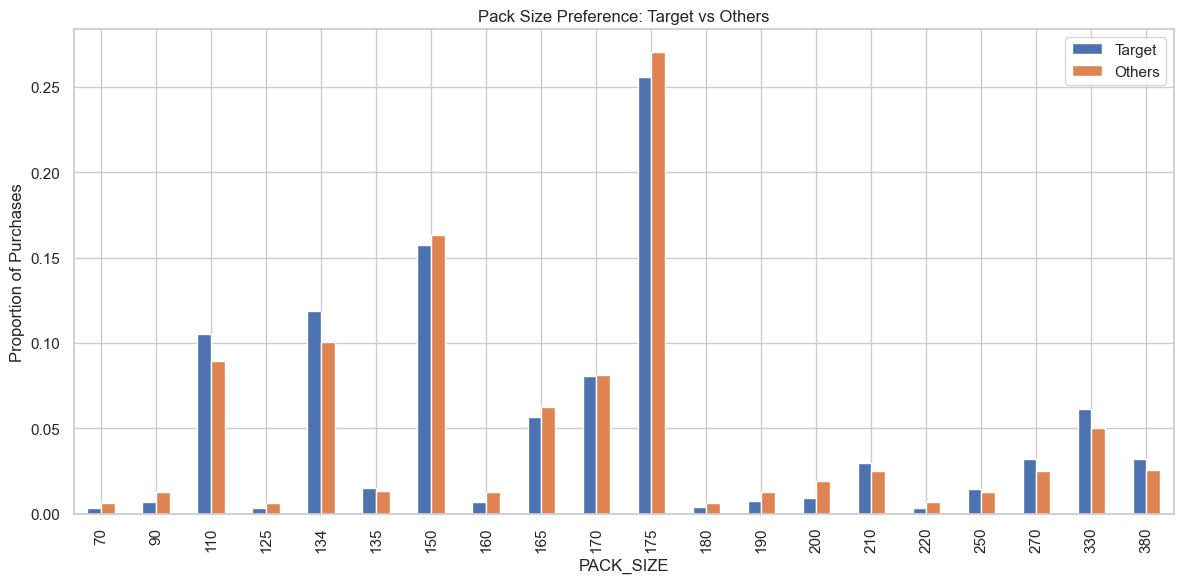

In [58]:
# Pack size preference for target vs others
pack_size_target = target_segment['PACK_SIZE'].value_counts(normalize=True)
pack_size_others = data[~data.index.isin(target_segment.index)]['PACK_SIZE'].value_counts(normalize=True)

pack_size_comparison = pd.DataFrame({'Target': pack_size_target, 'Others': pack_size_others}).fillna(0)
pack_size_comparison.plot(kind='bar', figsize=(12,6), title="Pack Size Preference: Target vs Others")
plt.ylabel("Proportion of Purchases")
plt.tight_layout()
plt.show()


In [59]:
# Proportion of quantity by pack size in each group
quantity_segment1_by_pack = (
    segment1.groupby('PACK_SIZE')['PROD_QTY'].sum() / quantity_segment1
).reset_index(name='targetSegment')

quantity_other_by_pack = (
    other.groupby('PACK_SIZE')['PROD_QTY'].sum() / quantity_other
).reset_index(name='other')

# Merge and calculate pack affinity
pack_proportions = pd.merge(quantity_segment1_by_pack, quantity_other_by_pack, on='PACK_SIZE')
pack_proportions['affinityToPack'] = pack_proportions['targetSegment'] / pack_proportions['other']
pack_proportions = pack_proportions.sort_values(by='affinityToPack', ascending=False)

print(pack_proportions)


    PACK_SIZE  targetSegment     other  affinityToPack
17        270       0.031829  0.025096        1.268287
19        380       0.032160  0.025584        1.257030
18        330       0.061284  0.050162        1.221717
4         134       0.119420  0.100635        1.186670
2         110       0.106280  0.089791        1.183637
14        210       0.029124  0.025121        1.159318
5         135       0.014769  0.013075        1.129511
16        250       0.014355  0.012781        1.123166
9         170       0.080773  0.080986        0.997370
6         150       0.157598  0.163421        0.964372
10        175       0.254990  0.270007        0.944382
8         165       0.055652  0.062268        0.893757
12        190       0.007481  0.012442        0.601271
11        180       0.003589  0.006067        0.591538
7         160       0.006404  0.012373        0.517616
1          90       0.006349  0.012580        0.504698
3         125       0.003009  0.006037        0.498442
13        

In [60]:
print(data[data['PACK_SIZE'] == 270]['PROD_NAME'].unique())


['Twisties Cheese     270g' 'Twisties Chicken270g']
